In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gzip
from scipy.optimize import curve_fit

## 1.

In [2]:
# Parameters

a = 3 # kpc
b = 0.25*a # kpc
M = 40 # *10^10 M_sun
G = 43007.1

In [3]:
# Potential

def phi_MN(R,z):
    return -G*M/(R**2+(a+(z**2+b**2)**0.5)**2)**0.5

phi_MN = np.vectorize(phi_MN)

# Density

def rho_MN(R,z):
    return (b**2*M/(4*np.pi))*(a*R**2+(a+3*(z**2+b**2)**0.5)*(a+(z**2+b**2)**0.5)**2)/((R**2+(a+(z**2+b**2)**0.5)**2)**2.5*(z**2+b**2)**1.5)

In [4]:
zs = np.linspace(-4*a,4*a,100)
Rs = np.linspace(-6*a,6*a,100)

RR, zz = np.meshgrid(Rs,zs)

Phis = phi_MN(RR,zz)

zsp = np.linspace(-4*a,4*a,1000)
Rsp = np.linspace(-6*a,6*a,1000)

RRp, zzp = np.meshgrid(Rsp,zsp)

rhos = rho_MN(RRp,zzp)

[(-10.0, 10.0),
 (-10.0, 10.0),
 Text(0.5, 0, 'R'),
 Text(0, 0.5, 'z'),
 Text(0.5, 1.0, 'Potencial')]

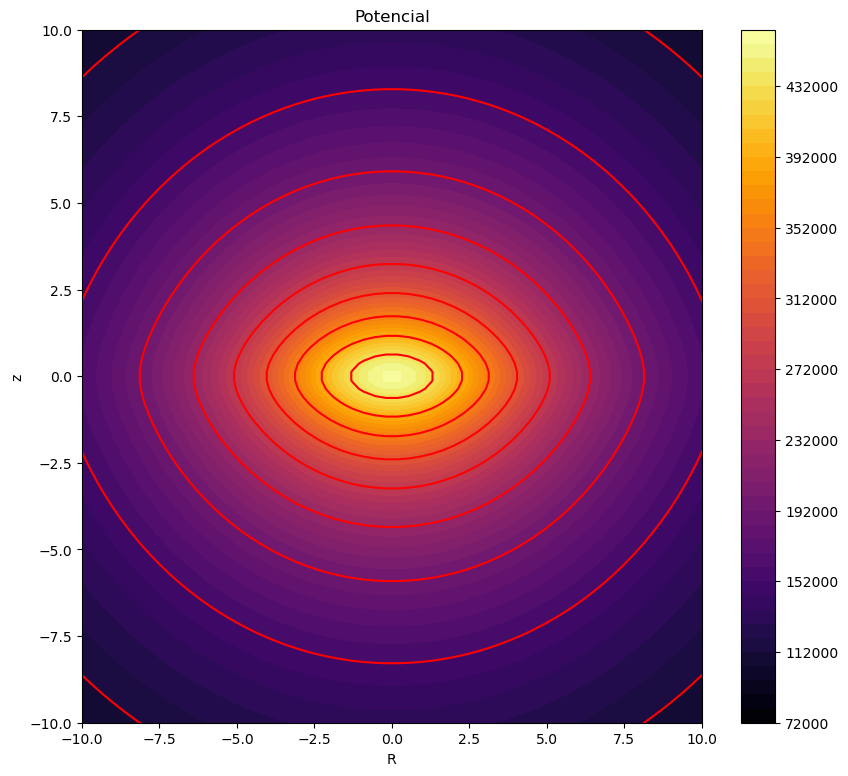

In [5]:
fig, ax = plt.subplots(figsize=(10,9))

CS = ax.contourf(RR,zz,-Phis,cmap='inferno',levels=50)
CS2 = ax.contour(CS, levels=CS.levels[::5], colors='r')
cbar = fig.colorbar(CS)
ax.set(xlim=(-10,10),ylim=(-10,10),xlabel='R',ylabel='z',title='Potencial')

[(-10.0, 10.0),
 (-10.0, 10.0),
 Text(0.5, 0, 'R'),
 Text(0, 0.5, 'z'),
 Text(0.5, 1.0, 'Densidad')]

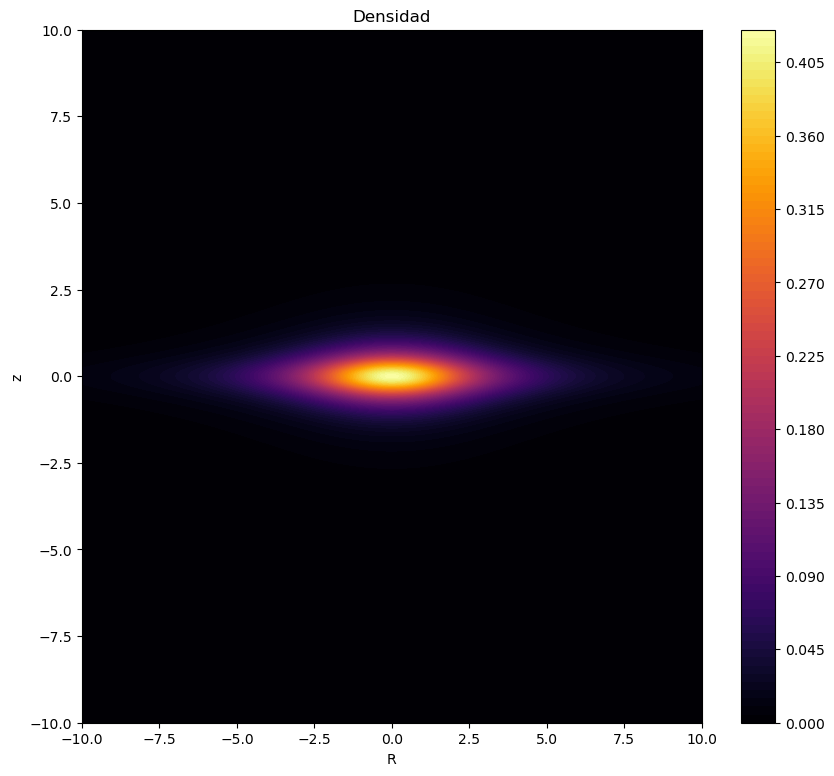

In [6]:
fig, ax = plt.subplots(figsize=(10,9))

CS = ax.contourf(RRp,zzp,rhos,cmap='inferno',levels=100)
#CS2 = ax.contour(CS, levels=CS.levels[::10], colors='r')
cbar = fig.colorbar(CS)
ax.set(xlim=(-10,10),ylim=(-10,10))
ax.set(xlim=(-10,10),ylim=(-10,10),xlabel='R',ylabel='z',title='Densidad')

In [7]:
# epicycle frequencies

def kappa(R):
    return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5)**0.5

def nu(R):
    return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5))**0.5

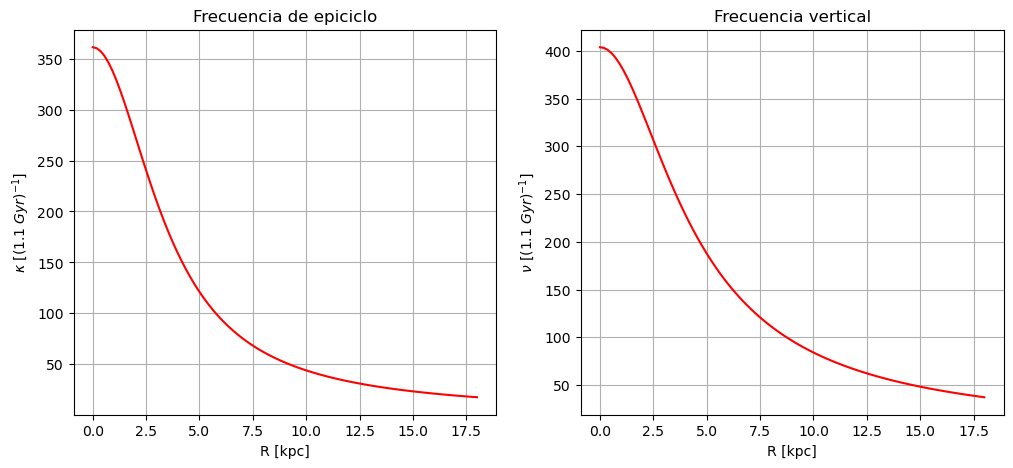

In [41]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

Rs = np.linspace(0,6*a,100)

ax[0].plot(Rs,kappa(Rs),'r')
ax[0].set(title='Frecuencia de epiciclo',xlabel='R [kpc]',ylabel=r'$\kappa$ [(1.1 $Gyr)^{-1}$]')
ax[0].grid()
ax[1].plot(Rs,nu(Rs),'r')
ax[1].set(title='Frecuencia vertical',xlabel='R [kpc]',ylabel=r'$\nu$ [(1.1 $Gyr)^{-1}$]')
ax[1].grid()

In [ ]:
def vert_osc(t,frec,z0,xi):
    return z0*np.cos(frec*t+xi)

def rad_osc(t,Rg,frec,x0,psi):
    return Rg + x0*np.cos(frec*t+psi)
    
def ang_osc(t,phi0,Omega0,Rg,frec,x0,psi):
    return phi0 + Omega0*t - 2*x0/(Rg*frec)*np.sin(frec*t+psi)

def Omega0_MN(Rg):
    return (G*M/((a+b)**2+Rg**2)**1.5)**0.5

In [70]:
Rg1 = 2.5
Rg2 = 10

ts1 = np.linspace(0,4*np.pi/Omega0_MN(Rg1),1000)
ts2 = np.linspace(0,4*np.pi/Omega0_MN(Rg2),1000)
angles = np.linspace(0,2*np.pi,1000)

xs_circ1 = Rg1*np.cos(angles)
ys_circ1 = Rg1*np.sin(angles)
zs_circ1 = np.zeros_like(xs_circ1)

xs_circ2 = Rg2*np.cos(angles)
ys_circ2 = Rg2*np.sin(angles)
zs_circ2 = np.zeros_like(xs_circ1)

R_pert1 = rad_osc(ts1,Rg1,kappa(Rg1),0.5,0)
z_pert1 = vert_osc(ts1,nu(Rg1),0.5,0)
phi_pert1 = ang_osc(ts1,0,Omega0_MN(Rg1),Rg1,kappa(Rg1),0.5,0)

xs_pert1 = R_pert1*np.cos(phi_pert1)
ys_pert1 = R_pert1*np.sin(phi_pert1)

R_pert2 = rad_osc(ts2,Rg2,kappa(Rg2),0.5,0)
z_pert2 = vert_osc(ts2,nu(Rg2),0.5,0)
phi_pert2 = ang_osc(ts2,0,Omega0_MN(Rg2),Rg2,kappa(Rg2),0.5,0)

xs_pert2 = R_pert2*np.cos(phi_pert2)
ys_pert2 = R_pert2*np.sin(phi_pert2)

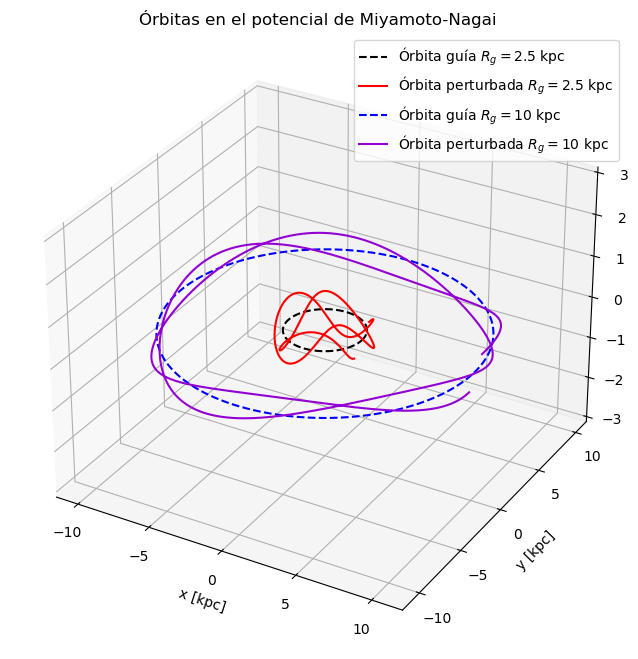

In [82]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.plot(xs_circ1,ys_circ1,zs_circ1,'k--',label=r'Órbita guía $R_g=2.5$ kpc')
ax.plot(xs_pert1,ys_pert1,z_pert1,'r',label=r'Órbita perturbada $R_g=2.5$ kpc')

ax.plot(xs_circ2,ys_circ2,zs_circ2,'b--',label=r'Órbita guía $R_g=10$ kpc')
ax.plot(xs_pert2,ys_pert2,z_pert2,'darkviolet',label=r'Órbita perturbada $R_g=10$ kpc')

ax.set(zlim=(-3,3),title='Órbitas en el potencial de Miyamoto-Nagai',xlabel='x [kpc]',ylabel='y [kpc]',zlabel='z [kpc]')
ax.legend()

## 2.

In [9]:
column_names = [
    "ID",
    "Epoca",
    "RA_deg",
    "Dec_deg",
    "Paralaje_arcsec",
    "MovimientoPropio_masyr",
    "Vr_kms",
    "Long_gal_deg",
    "Lat_gal_deg",
    "Dist_metodo1_pc",
    "Dist_metodo2_pc"
]

with gzip.open("subsample_GalEx_2M.txt.gz", "rt") as f:
    df = pd.read_csv(f, sep=",", header=None, names=column_names)

In [10]:
dfp = df.dropna(subset=['Vr_kms'])
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc
79,5621696888613016960,2016.0,133.258723,-39.523238,0.086473,3.757252,86.660645,261.141288,3.279331,6425.238280,8078.350100
89,6018044850158076672,2016.0,246.194342,-39.188157,3.737517,19.909462,-19.331419,341.727004,7.110754,268.027344,265.727661
113,4334984988063051392,2016.0,256.379667,-10.453017,7.635280,63.811234,7.392281,10.609667,17.909569,130.132538,130.152496
115,5518193949210533760,2016.0,117.748517,-48.672880,1.059334,6.113580,3.339843,262.374617,-11.035135,915.186646,914.578308
153,4353226504442695168,2016.0,249.861028,-5.540419,1.941453,32.428913,-14.634357,11.178116,26.002696,504.268921,504.672821
...,...,...,...,...,...,...,...,...,...,...,...
1999854,201683490904057728,2016.0,75.222381,41.247468,0.617336,5.756928,-12.810690,164.699844,-0.559481,1518.173340,1513.504640
1999865,192584649928439040,2016.0,86.118948,41.025546,2.048161,4.369009,-19.408665,169.528219,6.079631,478.831879,479.001740
1999919,3183088949846923776,2016.0,75.380094,-9.757960,1.155761,3.270247,72.404465,209.233337,-28.816660,839.433716,834.639404
1999947,2105498766434635776,2016.0,286.718939,42.897459,2.224060,10.706657,1.007664,73.614135,15.456009,440.031219,440.226074


In [11]:
dfp['Dist_pc'] = dfp['Dist_metodo2_pc']
fill = dfp.loc[dfp['Dist_metodo2_pc'].isna(),'Dist_metodo1_pc']
dfp['Dist_pc'] = dfp['Dist_pc'].fillna(fill)
dfp = dfp[dfp['Dist_pc']<1500]
dfp

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\3258910606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Dist_pc'] = dfp['Dist_metodo2_pc']
C:\Users\santi\AppData\Local\Temp\ipykernel_22072\3258910606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Dist_pc'] = dfp['Dist_pc'].fillna(fill)


,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc
89,6018044850158076672,2016.0,246.194342,-39.188157,3.737517,19.909462,-19.331419,341.727004,7.110754,268.027344,265.727661,265.727661
113,4334984988063051392,2016.0,256.379667,-10.453017,7.635280,63.811234,7.392281,10.609667,17.909569,130.132538,130.152496,130.152496
115,5518193949210533760,2016.0,117.748517,-48.672880,1.059334,6.113580,3.339843,262.374617,-11.035135,915.186646,914.578308,914.578308
153,4353226504442695168,2016.0,249.861028,-5.540419,1.941453,32.428913,-14.634357,11.178116,26.002696,504.268921,504.672821,504.672821
178,5258677834621262080,2016.0,154.534866,-57.737682,1.664661,10.645828,31.618607,283.599815,-0.738379,694.151733,729.031677,729.031677
...,...,...,...,...,...,...,...,...,...,...,...,...
1999718,2893520227527929856,2016.0,95.193170,-30.603657,0.846843,5.726222,18.074230,238.095277,-19.531774,1155.709590,1158.692140,1158.692140
1999865,192584649928439040,2016.0,86.118948,41.025546,2.048161,4.369009,-19.408665,169.528219,6.079631,478.831879,479.001740,479.001740
1999919,3183088949846923776,2016.0,75.380094,-9.757960,1.155761,3.270247,72.404465,209.233337,-28.816660,839.433716,834.639404,834.639404
1999947,2105498766434635776,2016.0,286.718939,42.897459,2.224060,10.706657,1.007664,73.614135,15.456009,440.031219,440.226074,440.226074


In [12]:
yr = 365.25*24*3600
rad = 180/np.pi*3600*1000
mas = 1/rad
pc = 3.086e+13

v0 = 220.

In [13]:
dfp['Vt_kms'] = dfp['MovimientoPropio_masyr']*dfp['Dist_pc']*mas/yr*pc

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\3368658894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Vt_kms'] = dfp['MovimientoPropio_masyr']*dfp['Dist_pc']*mas/yr*pc


In [14]:
dfp['beta'] = np.arcsin(dfp['Dist_pc']/8000*np.sin(dfp['Long_gal_deg']*np.pi/180))

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\1424743636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['beta'] = np.arcsin(dfp['Dist_pc']/8000*np.sin(dfp['Long_gal_deg']*np.pi/180))


In [15]:
dfp['R_pc'] = (dfp['Dist_pc']**2+8000**2-2*dfp['Dist_pc']*8000*np.cos((dfp['Long_gal_deg']%180)*np.pi/180))**0.5

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\1007569657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['R_pc'] = (dfp['Dist_pc']**2+8000**2-2*dfp['Dist_pc']*8000*np.cos((dfp['Long_gal_deg']%180)*np.pi/180))**0.5


In [16]:
dfp['Vc_kms'] = dfp['R_pc']*(dfp['Vr_kms']+220*np.sin(dfp['Long_gal_deg']*np.pi/180))/(8000*np.sin(dfp['Long_gal_deg']*np.pi/180))

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\3161097963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Vc_kms'] = dfp['R_pc']*(dfp['Vr_kms']+220*np.sin(dfp['Long_gal_deg']*np.pi/180))/(8000*np.sin(dfp['Long_gal_deg']*np.pi/180))


In [17]:
dfp = dfp.sort_values(by=['R_pc'])

In [18]:
np.min(dfp['beta'])

-0.1883726659005496

In [19]:
np.mean(dfp['beta']**2)**0.5

0.07696271274792431

In [20]:
dfp = dfp[np.abs(dfp['beta']) < 0.01]

In [21]:
dfp['A'] = dfp['Vr_kms']/(dfp['Dist_pc']/1000*np.sin(2*dfp['Long_gal_deg']*np.pi/180))
np.mean(dfp['A'])

174.7044207386648

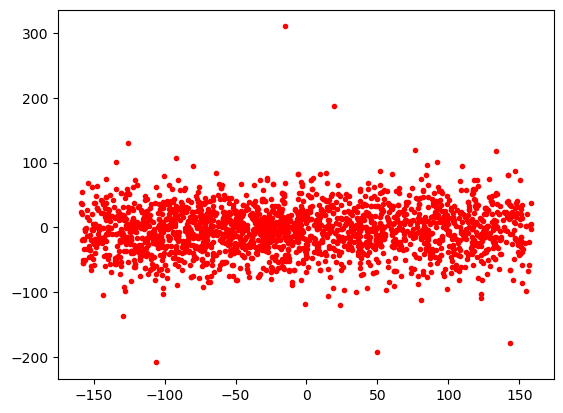

In [22]:
plt.plot(dfp['Dist_pc']*np.sin(2*np.pi/180*dfp['Long_gal_deg']),dfp['Vr_kms'],'r.')

(0.0, 500.0)

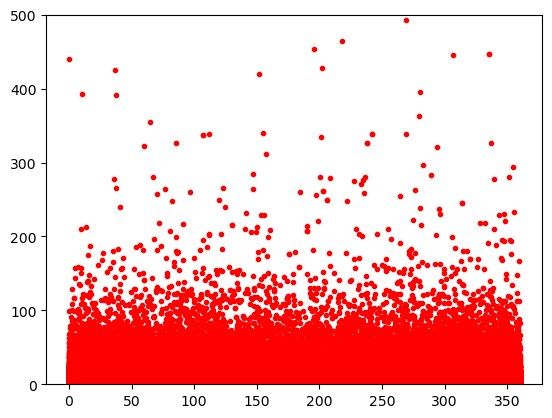

In [23]:
plt.plot(df['Long_gal_deg'],df['MovimientoPropio_masyr'],'r.')
plt.ylim(0,500)

In [24]:
def line(x,m,b):
    return m*x+b

In [25]:
xsA = np.sin(2*np.pi/180*dfp['Long_gal_deg'])*dfp['Dist_pc']/1000
ysA = dfp['Vr_kms']

parsA,covA = curve_fit(line,xsA,ysA)

In [26]:
parsA

array([19.4040019 , -4.24156117])

In [27]:
df['Dist_pc'] = df['Dist_metodo2_pc']
fill = df.loc[df['Dist_metodo2_pc'].isna(),'Dist_metodo1_pc']
df['Dist_pc'] = df['Dist_pc'].fillna(fill)
df

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc
0,4197265895348110208,2016.0,298.614329,-5.310397,0.530950,6.087040,NaN,35.376319,-16.428341,2735.59546,9693.20996,9693.20996
1,4085039160133824128,2016.0,284.722491,-20.315180,0.082032,5.789214,NaN,15.456506,-10.687023,5718.59326,6293.54443,6293.54443
2,5336002536054942976,2016.0,172.086420,-60.506735,-0.417030,4.400174,NaN,292.875110,0.732370,5777.67480,6193.11865,6193.11865
3,4120694844750771456,2016.0,267.560653,-17.710976,0.204952,9.070207,NaN,10.179022,4.874814,5552.92627,7217.31299,7217.31299
4,4136047634834911488,2016.0,258.889256,-16.397909,1.427181,4.051050,NaN,6.856883,12.599456,5617.32959,4887.94971,4887.94971
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,5859654397722345984,2016.0,185.375020,-67.208198,-0.080112,8.152262,NaN,300.030601,-4.505247,6602.07617,4993.52686,4993.52686
1999996,6043742086166538240,2016.0,242.374945,-25.183261,0.269193,2.429809,NaN,349.720317,19.200180,4228.62109,3699.43213,3699.43213
1999997,5966065236101431808,2016.0,257.765590,-40.907259,0.800141,3.859567,NaN,346.127998,-0.763886,4447.78076,6635.56104,6635.56104
1999998,4533207624393483904,2016.0,283.501211,23.197747,0.155786,2.933200,NaN,54.065394,9.814135,4166.23438,5009.70166,5009.70166


In [35]:
df['x'] = df['Dist_pc']*np.cos(df['Long_gal_deg']*np.pi/180)*np.cos(df['Lat_gal_deg']*np.pi/180)
df['y'] = df['Dist_pc']*np.sin(df['Long_gal_deg']*np.pi/180)*np.cos(df['Lat_gal_deg']*np.pi/180)
df['z'] = df['Dist_pc']*np.sin(df['Lat_gal_deg']*np.pi/180)
df

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,x,y,z
0,4197265895348110208,2016.0,298.614329,-5.310397,0.530950,6.087040,NaN,35.376319,-16.428341,2735.59546,9693.20996,9693.20996,7580.857227,5382.720494,-2741.394373
1,4085039160133824128,2016.0,284.722491,-20.315180,0.082032,5.789214,NaN,15.456506,-10.687023,5718.59326,6293.54443,6293.54443,5960.711507,1648.179771,-1167.100366
2,5336002536054942976,2016.0,172.086420,-60.506735,-0.417030,4.400174,NaN,292.875110,0.732370,5777.67480,6193.11865,6193.11865,2407.215585,-5705.590719,79.159899
3,4120694844750771456,2016.0,267.560653,-17.710976,0.204952,9.070207,NaN,10.179022,4.874814,5552.92627,7217.31299,7217.31299,7078.019280,1270.861508,613.319573
4,4136047634834911488,2016.0,258.889256,-16.397909,1.427181,4.051050,NaN,6.856883,12.599456,5617.32959,4887.94971,4887.94971,4736.122865,569.517873,1066.227914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,5859654397722345984,2016.0,185.375020,-67.208198,-0.080112,8.152262,NaN,300.030601,-4.505247,6602.07617,4993.52686,4993.52686,2491.350938,-4309.829002,-392.243520
1999996,6043742086166538240,2016.0,242.374945,-25.183261,0.269193,2.429809,NaN,349.720317,19.200180,4228.62109,3699.43213,3699.43213,3437.573674,-623.453892,1216.630826
1999997,5966065236101431808,2016.0,257.765590,-40.907259,0.800141,3.859567,NaN,346.127998,-0.763886,4447.78076,6635.56104,6635.56104,6441.454120,-1590.758661,-88.464805
1999998,4533207624393483904,2016.0,283.501211,23.197747,0.155786,2.933200,NaN,54.065394,9.814135,4166.23438,5009.70166,5009.70166,2896.976693,3996.931708,853.916674


In [37]:
dfp['x'] = dfp['Dist_pc']*np.cos(dfp['Long_gal_deg']*np.pi/180)*np.cos(dfp['Lat_gal_deg']*np.pi/180)
dfp['y'] = dfp['Dist_pc']*np.sin(dfp['Long_gal_deg']*np.pi/180)*np.cos(dfp['Lat_gal_deg']*np.pi/180)
dfp['z'] = dfp['Dist_pc']*np.sin(dfp['Lat_gal_deg']*np.pi/180)
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,Vt_kms,beta,R_pc,Vc_kms,A,x,y,z
1048399,896197329208242816,2016.0,115.555988,38.403731,0.619711,3.550090,34.156440,181.114712,25.883649,1509.02942,1499.35889,1499.35889,25.235495,-0.003646,6500.990302,-1247.977800,585.607305,-1348.691515,-26.242641,654.537701
270585,3309684691445072512,2016.0,69.929899,15.253464,0.425868,30.670053,32.437310,182.626706,-20.291482,1780.96863,1487.43945,1487.43945,216.282133,-0.008521,6514.480036,-397.217314,238.174615,-1393.663868,-63.936845,-515.838367
1375272,6731928376802858880,2016.0,283.236217,-35.867444,0.637382,12.343431,-106.032166,0.292797,-15.777871,1464.94080,1470.53723,1470.53723,86.055518,0.000939,6529.486296,-16755.411902,-7054.969265,1415.113445,7.231678,-399.851703
1041694,3417309047100212736,2016.0,81.212718,24.702049,0.630607,5.089613,-13.321844,181.074394,-6.183005,1464.79980,1468.12427,1468.12427,35.425370,-0.003441,6532.191844,759.755037,-242.009415,-1459.327517,-27.368107,-158.123550
856071,923279503191464704,2016.0,115.543411,39.310738,0.638897,8.726164,11.858762,180.137107,26.108721,1462.85364,1467.15051,1467.15051,60.696669,-0.000439,6532.854634,-3867.196729,1688.887430,-1317.439582,-3.152588,645.657515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72561,948734022007779712,2016.0,111.571346,41.382513,0.637204,3.894098,5.405234,177.048885,23.740013,1475.15027,1460.73328,1460.73328,26.967744,0.009401,9459.095050,384.262513,-35.984747,-1335.355192,68.840596,588.072444
506853,947015485333435008,2016.0,105.464998,38.417367,0.640928,9.167605,47.793667,178.488985,18.363275,1474.26147,1477.24670,1477.24670,64.206019,0.004869,9476.813081,2407.685580,-613.680813,-1401.535026,36.970117,465.392945
1058100,4056994466796642176,2016.0,264.586271,-29.883693,0.634420,2.748842,-20.322065,358.359080,0.845781,1487.98511,1482.36816,1482.36816,19.318466,-0.005306,9481.855286,1101.886010,239.471824,1481.598829,-42.443797,21.881434
850646,6734865889609117056,2016.0,277.843648,-34.581844,0.663597,4.562281,41.860302,359.670072,-11.229784,1472.34082,1483.29919,1483.29919,32.083195,-0.001068,9483.278445,-8356.612091,-2450.508963,1454.875905,-8.377755,-288.863983


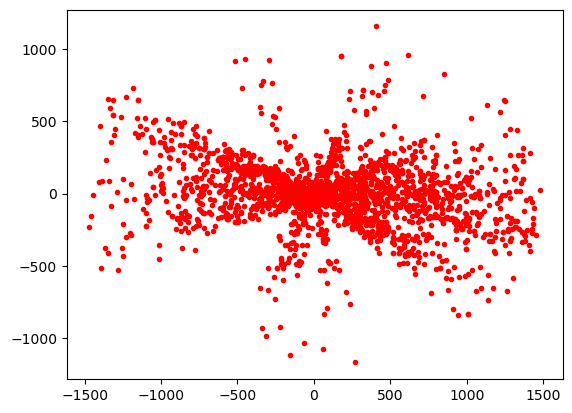

In [39]:
fig = plt.figure()
ax = fig.add_subplot()

df_ = df[(df['Lat_gal_deg']>-10) & (df['Lat_gal_deg']<10)]

ax.plot(dfp['x'], dfp['z'], 'r.')

(-20000.0, 20000.0)

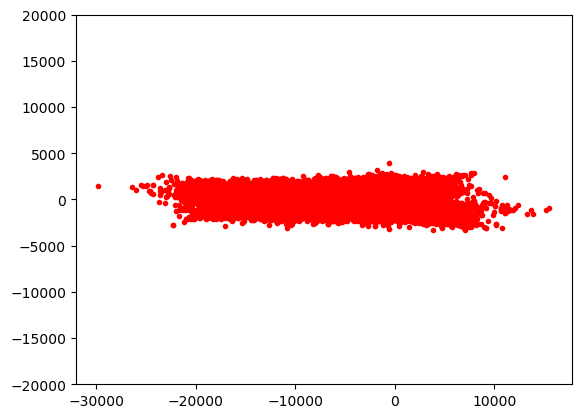

In [30]:
plt.plot(df_['x'], df_['z'], 'r.')
plt.ylim(-20000,20000)

In [31]:
np.min(dfp['Lat_gal_deg']),np.max(dfp['Lat_gal_deg'])

(-87.09435562791575, 87.04376940996687)

## 3.

In [89]:
Mh = 50 # 10^10 M_sun
alpha = 2

In [90]:
def kappa_corr(R):
    return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5+G*Mh*(R+3*alpha)/(R*(R+alpha)**3))**0.5

def nu_corr(R):
    return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5)+G*Mh/(R*(R+alpha)**2))**0.5

C:\Users\santi\AppData\Local\Temp\ipykernel_22072\1740084938.py:2: RuntimeWarning: divide by zero encountered in divide
  return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5+G*Mh*(R+3*alpha)/(R*(R+alpha)**3))**0.5
C:\Users\santi\AppData\Local\Temp\ipykernel_22072\1740084938.py:5: RuntimeWarning: divide by zero encountered in divide
  return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5)+G*Mh/(R*(R+alpha)**2))**0.5


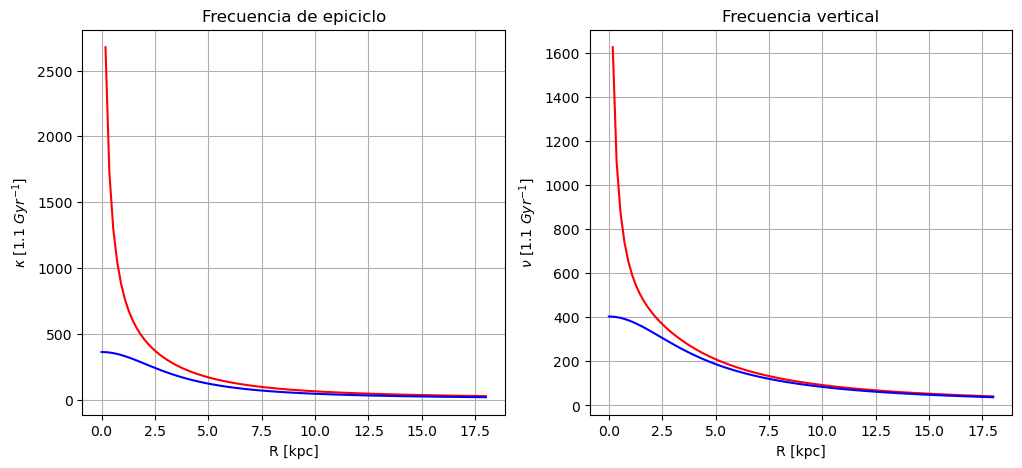

In [91]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

Rs = np.linspace(0,6*a,100)

ax[0].plot(Rs,kappa_corr(Rs),'r')
ax[0].plot(Rs,kappa(Rs),'b')
ax[0].set(title='Frecuencia de epiciclo',xlabel='R [kpc]',ylabel=r'$\kappa$ [1.1 $Gyr^{-1}$]')
ax[0].grid()
ax[1].plot(Rs,nu_corr(Rs),'r')
ax[1].plot(Rs,nu(Rs),'b')
ax[1].set(title='Frecuencia vertical',xlabel='R [kpc]',ylabel=r'$\nu$ [1.1 $Gyr^{-1}$]')
ax[1].grid()

In [92]:
def Omega0_corr(Rg):
    return (G*M/((a+b)**2+Rg**2)**1.5+G*Mh/(Rg*(Rg+alpha))**2)**0.5

In [93]:
Rg1 = 2.5
Rg2 = 10

ts1 = np.linspace(0,4*np.pi/Omega0_corr(Rg1),1000)
ts2 = np.linspace(0,4*np.pi/Omega0_corr(Rg2),1000)

R_pert1c = rad_osc(ts1,Rg1,kappa_corr(Rg1),0.5,0)
z_pert1c = vert_osc(ts1,nu_corr(Rg1),0.5,0)
phi_pert1c = ang_osc(ts1,0,Omega0_corr(Rg1),Rg1,kappa_corr(Rg1),0.5,0)

xs_pert1c = R_pert1c*np.cos(phi_pert1c)
ys_pert1c = R_pert1c*np.sin(phi_pert1c)

R_pert2c = rad_osc(ts2,Rg2,kappa_corr(Rg2),0.5,0)
z_pert2c = vert_osc(ts2,nu_corr(Rg2),0.5,0)
phi_pert2c = ang_osc(ts2,0,Omega0_corr(Rg2),Rg2,kappa_corr(Rg2),0.5,0)

xs_pert2c = R_pert2*np.cos(phi_pert2c)
ys_pert2c = R_pert2*np.sin(phi_pert2c)

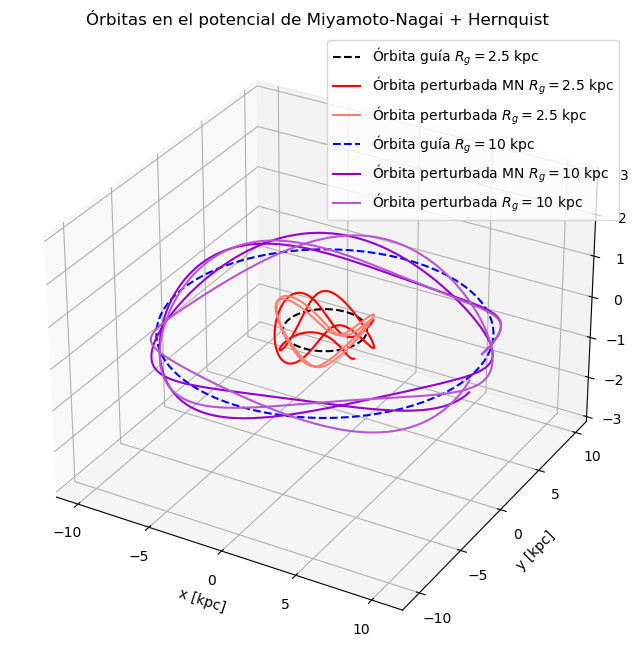

In [98]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.plot(xs_circ1,ys_circ1,zs_circ1,'k--',label=r'Órbita guía $R_g=2.5$ kpc')
ax.plot(xs_pert1,ys_pert1,z_pert1,'r',label=r'Órbita perturbada MN $R_g=2.5$ kpc')
ax.plot(xs_pert1c,ys_pert1c,z_pert1c,'salmon',label=r'Órbita perturbada $R_g=2.5$ kpc')

ax.plot(xs_circ2,ys_circ2,zs_circ2,'b--',label=r'Órbita guía $R_g=10$ kpc')
ax.plot(xs_pert2,ys_pert2,z_pert2,'darkviolet',label=r'Órbita perturbada MN $R_g=10$ kpc')
ax.plot(xs_pert2c,ys_pert2c,z_pert2c,'mediumorchid',label=r'Órbita perturbada $R_g=10$ kpc')

ax.set(zlim=(-3,3),title='Órbitas en el potencial de Miyamoto-Nagai + Hernquist',xlabel='x [kpc]',ylabel='y [kpc]',zlabel='z [kpc]')
ax.legend()